In [14]:
from pathlib import Path

ROOT = Path.cwd().parent
RUNS_DIR = ROOT / ".runs"

# Figures will be saved here for use in documentation
FIGURES_DIR = ROOT / "docs" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Map display names -> run directories
EXPERIMENT_DIRS = {
    "ViT": RUNS_DIR / "vit",
    "DeiT": RUNS_DIR / "deit",
    "WRN": RUNS_DIR / "wrn",
}

In [15]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

warnings.filterwarnings("ignore", category=FutureWarning)

# Plot style
plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "figure.figsize": (10, 5),
})


def save_figure(fig, filename: str):
    """Save a matplotlib figure to FIGURES_DIR at high resolution."""
    path = FIGURES_DIR / filename
    fig.savefig(path, dpi=150, bbox_inches="tight", facecolor="white")
    print(f"  [saved] {path}")

In [16]:
# ---------------------------------------------------------------------------
# Data loading utilities
# ---------------------------------------------------------------------------

def load_runs(directory: Path) -> dict[str, pd.DataFrame]:
    """Load all CSV logs from a run directory."""
    runs = {}
    for csv_file in sorted(directory.glob("logs/*.csv")):
        runs[csv_file.stem] = pd.read_csv(csv_file)
    return runs


def load_checkpoint_metadata(directory: Path) -> dict:
    """
    Load config + param count from the last checkpoint (if available).
    Returns a dict with keys: param_count, model_name, config.
    Falls back gracefully if checkpoint is missing or malformed.
    """
    ckpt_path = directory / "checkpoints" / "last.pt"
    if not ckpt_path.exists():
        return {"param_count": None, "model_name": None, "config": None}
    try:
        ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=False)
        param_count = (
            sum(v.numel() for v in ckpt["model"].values())
            if "model" in ckpt else None
        )
        return {
            "param_count": param_count,
            "model_name": ckpt.get("model_name", None),
            "config": ckpt.get("config", None),
        }
    except Exception:
        return {"param_count": None, "model_name": None, "config": None}


def load_all_experiments(
    experiment_dirs: dict[str, Path],
) -> tuple[dict[str, dict[str, pd.DataFrame]], dict[str, dict]]:
    """
    Load all CSV logs and checkpoint metadata.

    Returns:
        experiments: {model_label: {run_name: df}}
        metadata:    {model_label: {param_count, model_name, config}}
    """
    experiments = {}
    metadata = {}
    for label, directory in experiment_dirs.items():
        experiments[label] = load_runs(directory)
        metadata[label] = load_checkpoint_metadata(directory)
    return experiments, metadata


# ---------------------------------------------------------------------------
# Summary table construction
# ---------------------------------------------------------------------------

def make_summary_row(label: str, run_name: str, df: pd.DataFrame, meta: dict) -> dict:
    """Create a single summary row for one run."""
    last_row = df.iloc[-1]
    best_acc_val = df["best_acc"].max()
    best_epoch = df.loc[df["best_acc"] == best_acc_val, "epoch"].iloc[0]

    return {
        "Architecture": label,
        "Run": run_name,
        "Best Acc (%)": best_acc_val,
        "Best Epoch": int(best_epoch),
        "Final Val Acc (%)": last_row["val_acc"],
        "Final Val Loss": last_row["val_loss"],
        "Final Train Loss": last_row["train_loss"],
        "Params (M)": (
            f"{meta['param_count'] / 1e6:.3f}"
            if meta["param_count"] else "N/A"
        ),
        "Epochs": len(df),
    }


def create_results_table(
    experiments: dict[str, dict[str, pd.DataFrame]],
    metadata: dict[str, dict],
) -> pd.DataFrame:
    """Build summary DataFrame with one row per run."""
    rows = []
    for label, runs in experiments.items():
        meta = metadata[label]
        for run_name, df in runs.items():
            rows.append(make_summary_row(label, run_name, df, meta))
    results = pd.DataFrame(rows)
    return results.sort_values(
        by="Best Acc (%)", ascending=False
    ).reset_index(drop=True)

In [17]:
experiments, metadata = load_all_experiments(EXPERIMENT_DIRS)
results_df = create_results_table(experiments, metadata)
results_df

,Architecture,Run,Best Acc (%),Best Epoch,Final Val Acc (%),Final Val Loss,Final Train Loss,Params (M),Epochs
0,WRN,metrics,96.59,294,96.50,0.285673,1.044480,2.753,300
1,DeiT,metrics,93.15,300,93.15,0.253332,0.547177,2.856,300
2,ViT,metrics,89.55,243,89.26,0.429522,1.060269,2.694,300


In [18]:
# ---------------------------------------------------------------------------
# Styled summary table with best-value highlighting
# ---------------------------------------------------------------------------

def style_results_table(df: pd.DataFrame):
    """Return a styled version of the results table.

    - Best Acc, Final Val Acc, Best Epoch (lower is better): highlight best
    - Params (M) (lower is better when accuracy is close)
    """
    df_display = df.copy()

    if "Params (M)" in df_display.columns:
        df_display["Params (M)"] = pd.to_numeric(
            df_display["Params (M)"], errors="coerce"
        )

    styler = df_display.style
    styler = styler.highlight_max(
        subset=["Best Acc (%)"],
        color="lightgreen",
        props="font-weight: bold; background-color: lightgreen",
    )
    if "Best Epoch" in df_display.columns:
        styler = styler.highlight_min(
            subset=["Best Epoch"],
            color="lightblue",
            props="font-weight: bold; background-color: lightblue",
        )
    if "Params (M)" in df_display.columns and df_display["Params (M)"].notna().any():
        styler = styler.highlight_min(
            subset=["Params (M)"],
            color="lightyellow",
            props="font-weight: bold; background-color: lightyellow",
        )
    styler = styler.format({
        "Best Acc (%)": "{:.2f}",
        "Final Val Acc (%)": "{:.2f}",
        "Final Val Loss": "{:.4f}",
        "Final Train Loss": "{:.4f}",
        "Params (M)": "{:.3f}",
    })
    return styler


display(style_results_table(results_df))

,Architecture,Run,Best Acc (%),Best Epoch,Final Val Acc (%),Final Val Loss,Final Train Loss,Params (M),Epochs
0,WRN,metrics,96.59,294,96.50,0.2857,1.0445,2.753,300
1,DeiT,metrics,93.15,300,93.15,0.2533,0.5472,2.856,300
2,ViT,metrics,89.55,243,89.26,0.4295,1.0603,2.694,300


In [19]:
# ---------------------------------------------------------------------------
# Export Markdown table to file
# ---------------------------------------------------------------------------

def results_to_markdown(df: pd.DataFrame) -> str:
    """Export the results table as a clean Markdown table."""
    out = df.copy()
    for col in ["Best Acc (%)", "Final Val Acc (%)"]:
        if col in out.columns:
            out[col] = out[col].round(2)
    for col in ["Final Val Loss", "Final Train Loss"]:
        if col in out.columns:
            out[col] = out[col].round(4)
    return out.to_markdown(index=False, floatfmt=".4f")


markdown_table = results_to_markdown(results_df)

# Display in notebook
from IPython.display import Markdown
display(Markdown("## Benchmark Results\n" + markdown_table))

# Save to file for use in documentation
md_path = FIGURES_DIR / "results_table.md"
with open(md_path, "w") as f:
    f.write("# Benchmark Results\n\n")
    f.write(markdown_table)
    f.write("\n")
print(f"[saved] {md_path}")

## Benchmark Results
| Architecture   | Run     |   Best Acc (%) |   Best Epoch |   Final Val Acc (%) |   Final Val Loss |   Final Train Loss |   Params (M) |   Epochs |
|:---------------|:--------|---------------:|-------------:|--------------------:|-----------------:|-------------------:|-------------:|---------:|
| WRN            | metrics |        96.5900 |          294 |             96.5000 |           0.2857 |             1.0445 |       2.7530 |      300 |
| DeiT           | metrics |        93.1500 |          300 |             93.1500 |           0.2533 |             0.5472 |       2.8560 |      300 |
| ViT            | metrics |        89.5500 |          243 |             89.2600 |           0.4295 |             1.0603 |       2.6940 |      300 |

[saved] /Users/esteban/src/cifar10/docs/figures/results_table.md


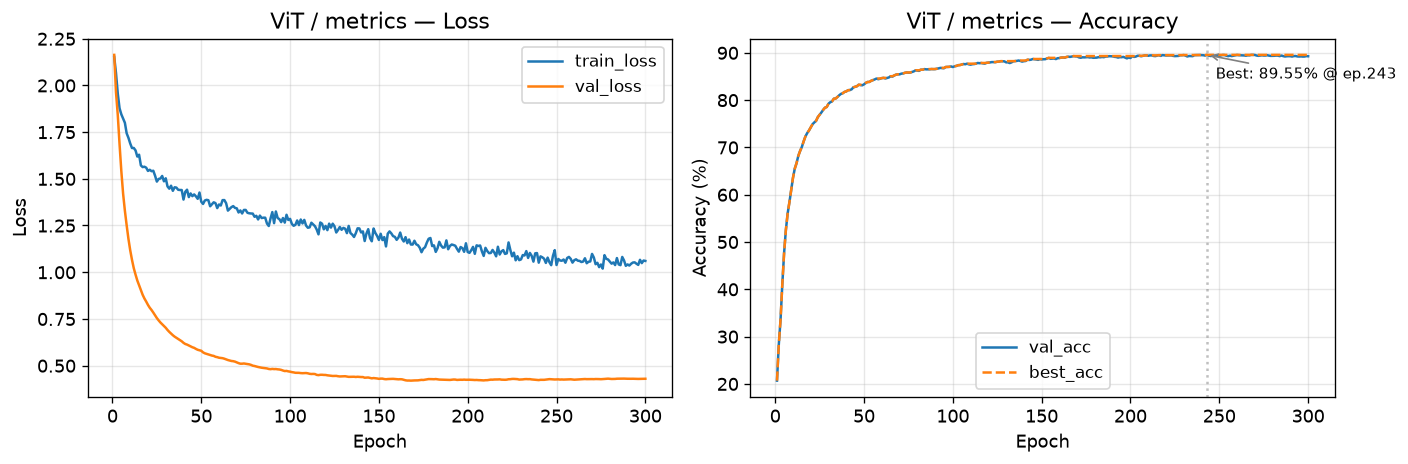

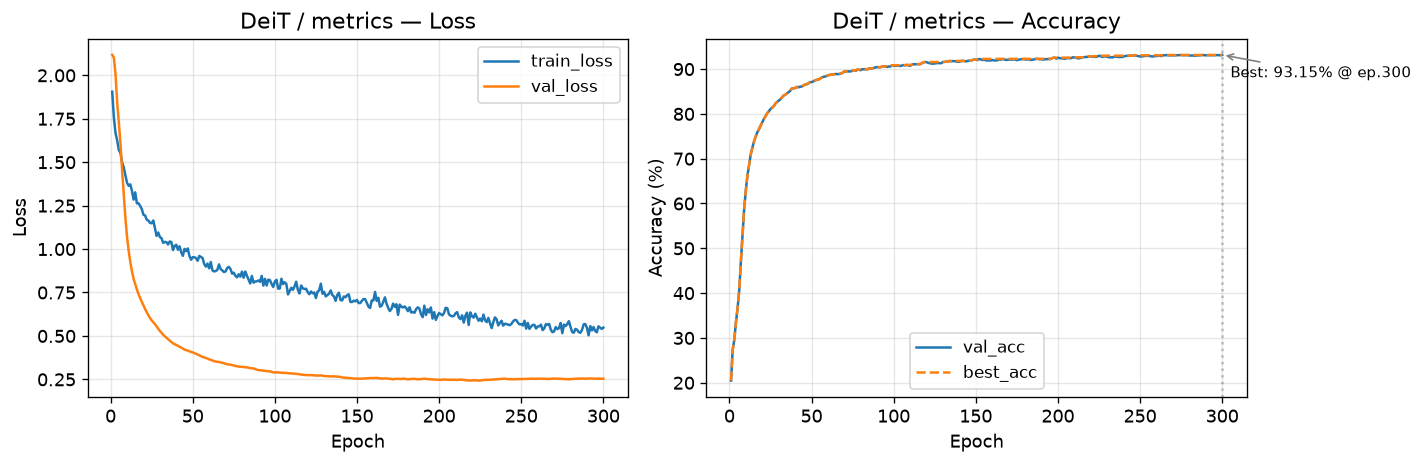

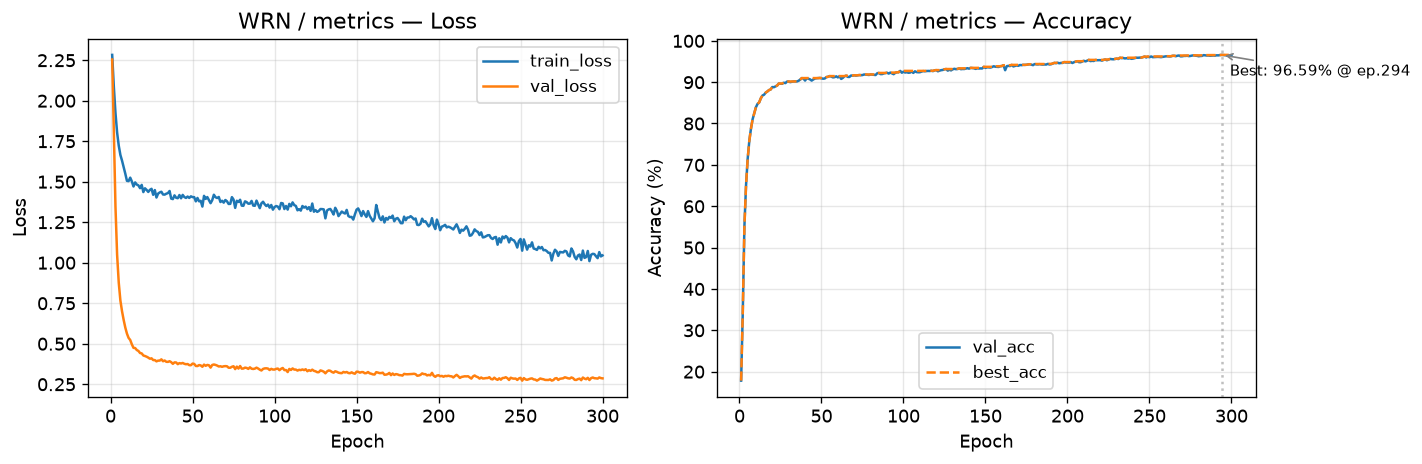

In [20]:
# ---------------------------------------------------------------------------
# Individual run plots (loss + accuracy)
# ---------------------------------------------------------------------------

def plot_run(df: pd.DataFrame, title: str, save_name: str = None):
    """Plot loss and accuracy for a single run.

    Args:
        df: Run dataframe.
        title: Plot title.
        save_name: If given, saves the figure to FIGURES_DIR / save_name.
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Loss
    axes[0].plot(df["epoch"], df["train_loss"], label="train_loss", lw=1.5)
    axes[0].plot(df["epoch"], df["val_loss"], label="val_loss", lw=1.5)
    axes[0].set_title(f"{title} \u2014 Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    # Accuracy
    best_epoch = df.loc[df["best_acc"].idxmax(), "epoch"]
    best_val = df["best_acc"].max()
    axes[1].plot(df["epoch"], df["val_acc"], label="val_acc", lw=1.5)
    axes[1].plot(df["epoch"], df["best_acc"], label="best_acc", lw=1.5, ls="--")
    axes[1].axvline(best_epoch, color="gray", ls=":", alpha=0.5)
    axes[1].annotate(
        f"Best: {best_val:.2f}% @ ep.{int(best_epoch)}",
        xy=(best_epoch, best_val),
        xytext=(best_epoch + 5, best_val - 5),
        fontsize=9,
        arrowprops=dict(arrowstyle="->", color="gray", lw=1),
    )
    axes[1].set_title(f"{title} \u2014 Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy (%)")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    if save_name:
        save_figure(fig, save_name)
    plt.show()


for model_name, runs in experiments.items():
    for run_name, df in runs.items():
        plot_run(df, f"{model_name} / {run_name}")

## Validation Accuracy — All Runs
  [saved] /Users/esteban/src/cifar10/docs/figures/val_acc_comparison.png


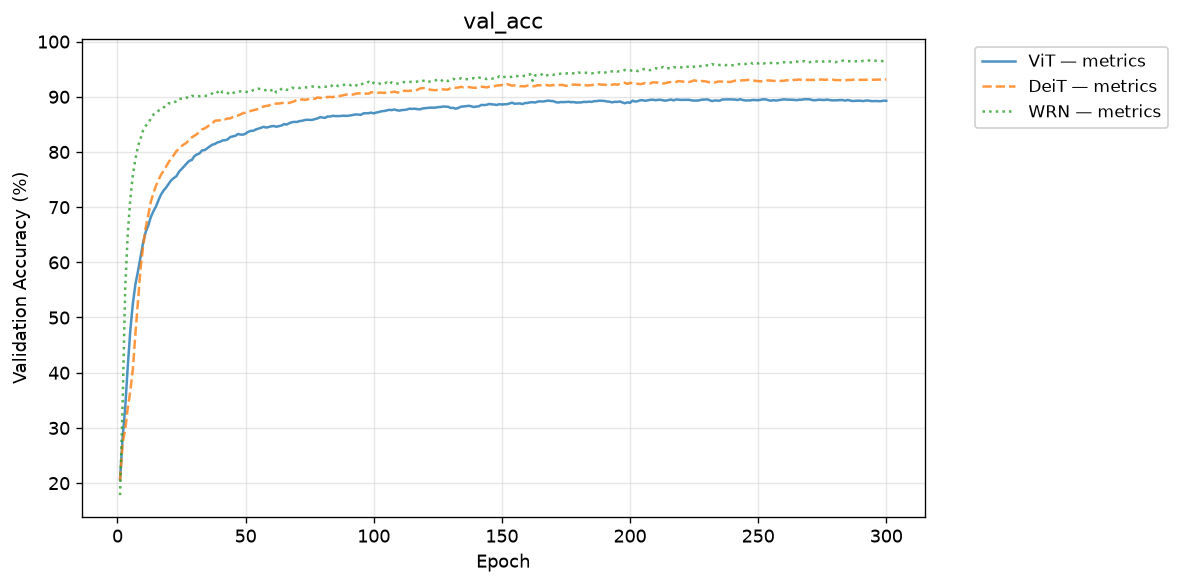

## Validation Loss — All Runs
  [saved] /Users/esteban/src/cifar10/docs/figures/val_loss_comparison.png


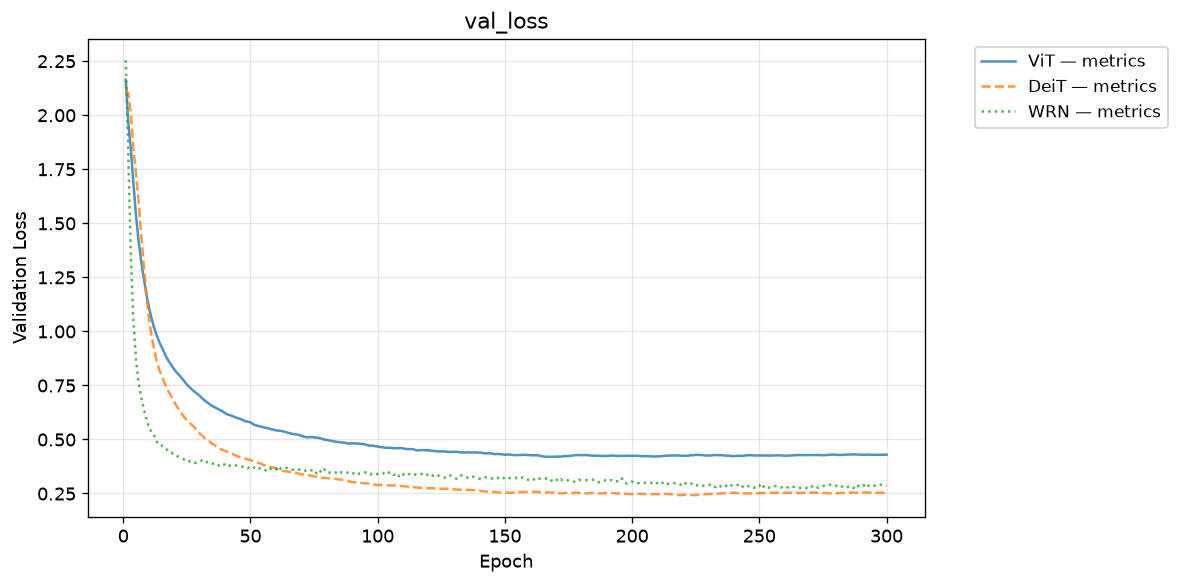

## Best Run per Architecture
  [saved] /Users/esteban/src/cifar10/docs/figures/best_accuracy.png


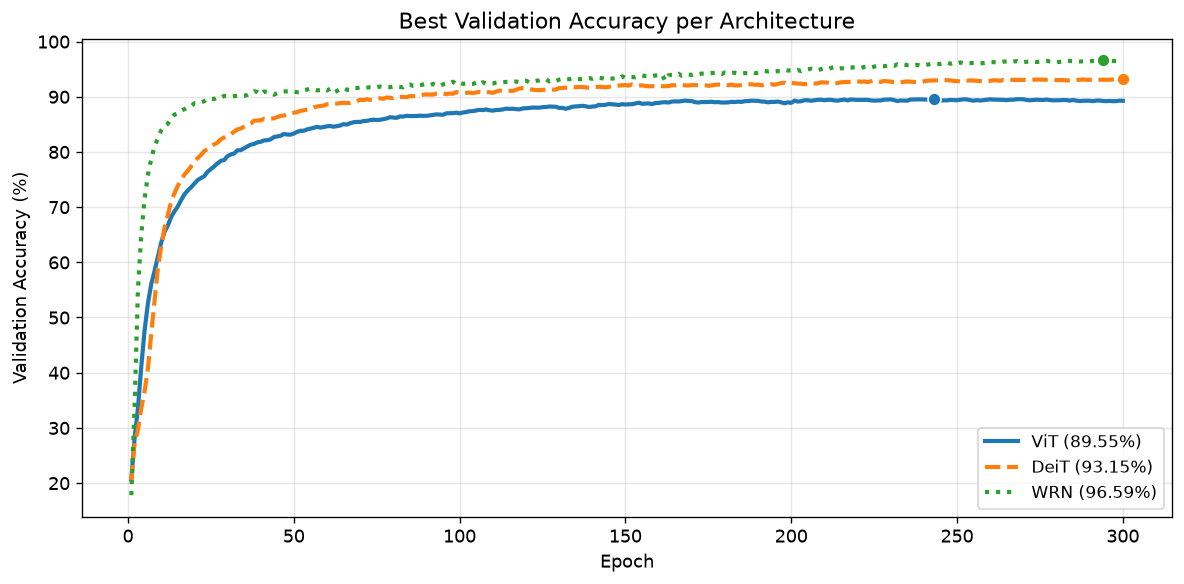

In [21]:
# ---------------------------------------------------------------------------
# Comparison plots (all runs overlaid per metric)
# ---------------------------------------------------------------------------

MODEL_COLORS = {
    "ViT": "#1f77b4",
    "DeiT": "#ff7f0e",
    "WRN": "#2ca02c",
}
MODEL_LINESTYLES = {
    "ViT": "-",
    "DeiT": "--",
    "WRN": ":",
}


def plot_metric_comparison(experiments, metric: str, ylabel: str = None,
                           save_name: str = None):
    """Plot one metric for all runs, grouped by architecture."""
    fig, ax = plt.subplots()

    for model_name, runs in experiments.items():
        color = MODEL_COLORS.get(model_name, "gray")
        ls = MODEL_LINESTYLES.get(model_name, "-")
        for run_name, df in runs.items():
            label = f"{model_name} \u2014 {run_name}"
            ax.plot(df["epoch"], df[metric], label=label,
                    color=color, ls=ls, lw=1.5, alpha=0.8)

    ax.set_title(metric)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel or metric)
    ax.grid(True, alpha=0.3)
    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", framealpha=0.9)
    plt.tight_layout()
    if save_name:
        save_figure(fig, save_name)
    plt.show()


# --- Best run per architecture ---

def get_best_run(runs: dict[str, pd.DataFrame]):
    """Return (run_name, df, best_accuracy) for the best run."""
    best_name = None
    best_df = None
    best_acc = -1
    for run_name, df in runs.items():
        run_best = df["best_acc"].max()
        if run_best > best_acc:
            best_acc = run_best
            best_name = run_name
            best_df = df
    return best_name, best_df, best_acc


def plot_best_runs_comparison(experiments, save_name: str = None):
    """Compare only the best run of each architecture with accuracy marker."""
    fig, ax = plt.subplots()

    for model_name, runs in experiments.items():
        run_name, df, best_acc = get_best_run(runs)
        color = MODEL_COLORS.get(model_name, "gray")
        ls = MODEL_LINESTYLES.get(model_name, "-")
        ax.plot(df["epoch"], df["val_acc"],
                label=f"{model_name} ({best_acc:.2f}%)",
                color=color, ls=ls, lw=2.5)
        best_row = df.loc[df["best_acc"].idxmax()]
        ax.scatter([best_row["epoch"]], [best_row["best_acc"]],
                   color=color, s=60, zorder=5,
                   edgecolors="white", linewidths=1)

    ax.set_title("Best Validation Accuracy per Architecture")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Validation Accuracy (%)")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    if save_name:
        save_figure(fig, save_name)
    plt.show()


# --- Generate comparison plots & save ---
print("## Validation Accuracy \u2014 All Runs")
plot_metric_comparison(experiments, "val_acc",
                       ylabel="Validation Accuracy (%)",
                       save_name="val_acc_comparison.png")

print("## Validation Loss \u2014 All Runs")
plot_metric_comparison(experiments, "val_loss",
                       ylabel="Validation Loss",
                       save_name="val_loss_comparison.png")

print("## Best Run per Architecture")
plot_best_runs_comparison(experiments, save_name="best_accuracy.png")

## Learning Rate Schedules
  [saved] /Users/esteban/src/cifar10/docs/figures/lr_schedules.png


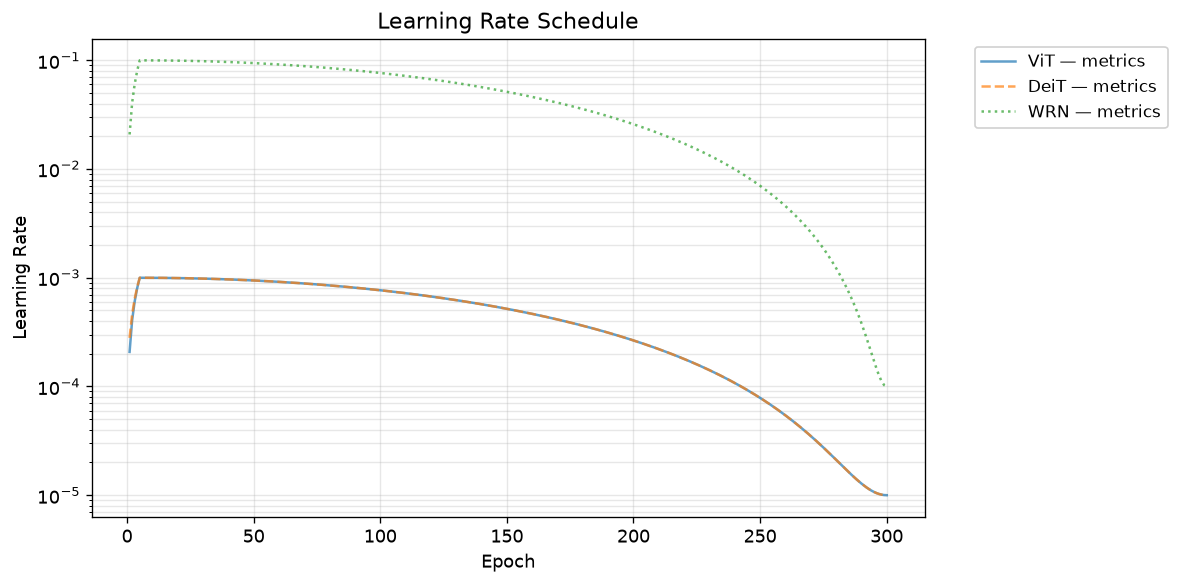

In [22]:
# ---------------------------------------------------------------------------
# Learning Rate Schedule
# ---------------------------------------------------------------------------

def plot_lr_schedules(experiments, save_name: str = None):
    """Plot LR schedules for all runs."""
    fig, ax = plt.subplots()

    for model_name, runs in experiments.items():
        color = MODEL_COLORS.get(model_name, "gray")
        ls = MODEL_LINESTYLES.get(model_name, "-")
        for run_name, df in runs.items():
            lr_series = df["lr"].clip(lower=0)
            ax.plot(df["epoch"], lr_series,
                    label=f"{model_name} \u2014 {run_name}",
                    color=color, ls=ls, lw=1.5, alpha=0.7)

    ax.set_title("Learning Rate Schedule")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Learning Rate")
    ax.set_yscale("log")
    ax.grid(True, alpha=0.3, which="both")
    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", framealpha=0.9)
    plt.tight_layout()
    if save_name:
        save_figure(fig, save_name)
    plt.show()


print("## Learning Rate Schedules")
plot_lr_schedules(experiments, save_name="lr_schedules.png")

## Parameter Efficiency
  [saved] /Users/esteban/src/cifar10/docs/figures/param_efficiency.png


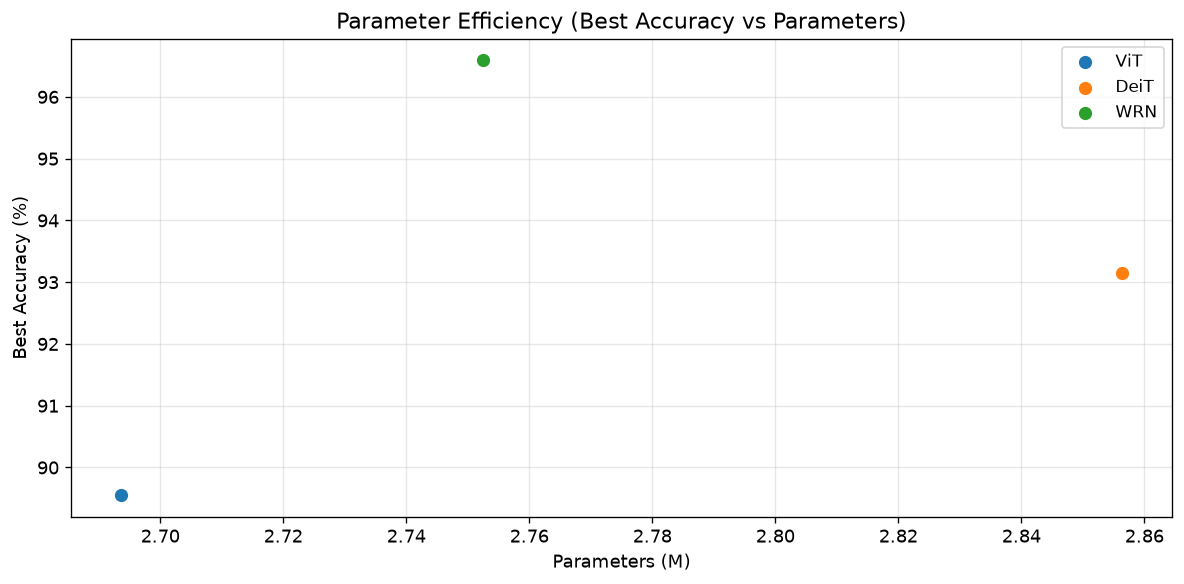

In [23]:
# ---------------------------------------------------------------------------
# Parameter Efficiency: Accuracy vs Parameter Count
# ---------------------------------------------------------------------------

def plot_param_efficiency(experiments, metadata, save_name: str = None):
    """Scatter plot: Best accuracy vs parameter count."""
    fig, ax = plt.subplots()

    for model_name, runs in experiments.items():
        meta = metadata[model_name]
        color = MODEL_COLORS.get(model_name, "gray")

        for run_name, df in runs.items():
            best_acc = df["best_acc"].max()
            param_count = meta["param_count"]
            if param_count is None:
                continue

            ax.scatter(
                param_count / 1e6, best_acc,
                color=color, s=80, zorder=5,
                edgecolors="white", linewidths=1,
                label=model_name if run_name == list(runs.keys())[0] else "",
            )
            if len(runs) > 1:
                ax.annotate(run_name, (param_count / 1e6, best_acc),
                            fontsize=8, xytext=(3, 3),
                            textcoords="offset points")

    ax.set_title("Parameter Efficiency (Best Accuracy vs Parameters)")
    ax.set_xlabel("Parameters (M)")
    ax.set_ylabel("Best Accuracy (%)")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    if save_name:
        save_figure(fig, save_name)
    plt.show()


print("## Parameter Efficiency")
plot_param_efficiency(experiments, metadata, save_name="param_efficiency.png")

## Convergence Speed Comparison
  [saved] /Users/esteban/src/cifar10/docs/figures/convergence.png


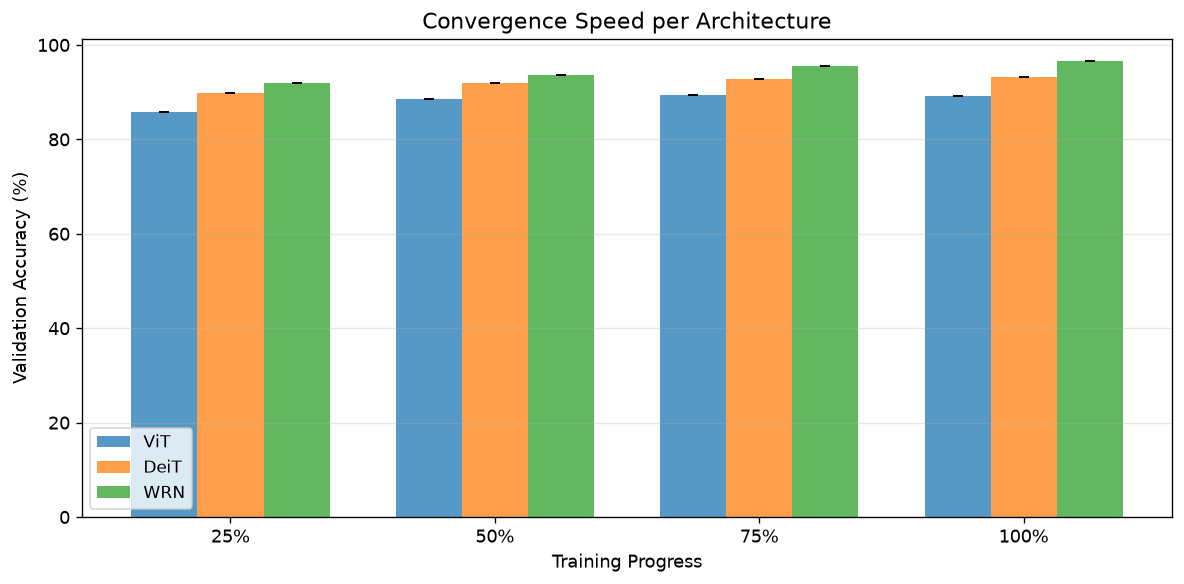

In [24]:
# ---------------------------------------------------------------------------
# Convergence Speed: Accuracy at 25%, 50%, 75%, 100% of training
# ---------------------------------------------------------------------------

def plot_convergence_summary(experiments, save_name: str = None):
    """
    Bar chart showing validation accuracy at 25%, 50%, 75%, 100% epochs.
    """
    checkpoints_pct = [0.25, 0.50, 0.75, 1.0]
    data = {label: [] for label in experiments}

    for label, runs in experiments.items():
        for run_name, df in runs.items():
            total = len(df)
            for pct in checkpoints_pct:
                idx = min(int(total * pct), total - 1)
                data[label].append(df.iloc[idx]["val_acc"])

    x = np.arange(len(checkpoints_pct))
    width = 0.25
    fig, ax = plt.subplots()

    for i, (label, values_list) in enumerate(data.items()):
        color = MODEL_COLORS.get(label, "gray")
        arr = np.array(values_list).reshape(-1, len(checkpoints_pct))
        means = arr.mean(axis=0)
        stds = arr.std(axis=0)
        offset = (i - 1) * width
        ax.bar(x + offset, means, width, label=label,
               color=color, alpha=0.75, yerr=stds, capsize=3)

    ax.set_title("Convergence Speed per Architecture")
    ax.set_xlabel("Training Progress")
    ax.set_ylabel("Validation Accuracy (%)")
    ax.set_xticks(x)
    ax.set_xticklabels([f"{int(p * 100)}%" for p in checkpoints_pct])
    ax.grid(True, alpha=0.3, axis="y")
    ax.legend()
    plt.tight_layout()
    if save_name:
        save_figure(fig, save_name)
    plt.show()


print("## Convergence Speed Comparison")
plot_convergence_summary(experiments, save_name="convergence.png")

## Dashboard
  [saved] /Users/esteban/src/cifar10/docs/figures/dashboard.png


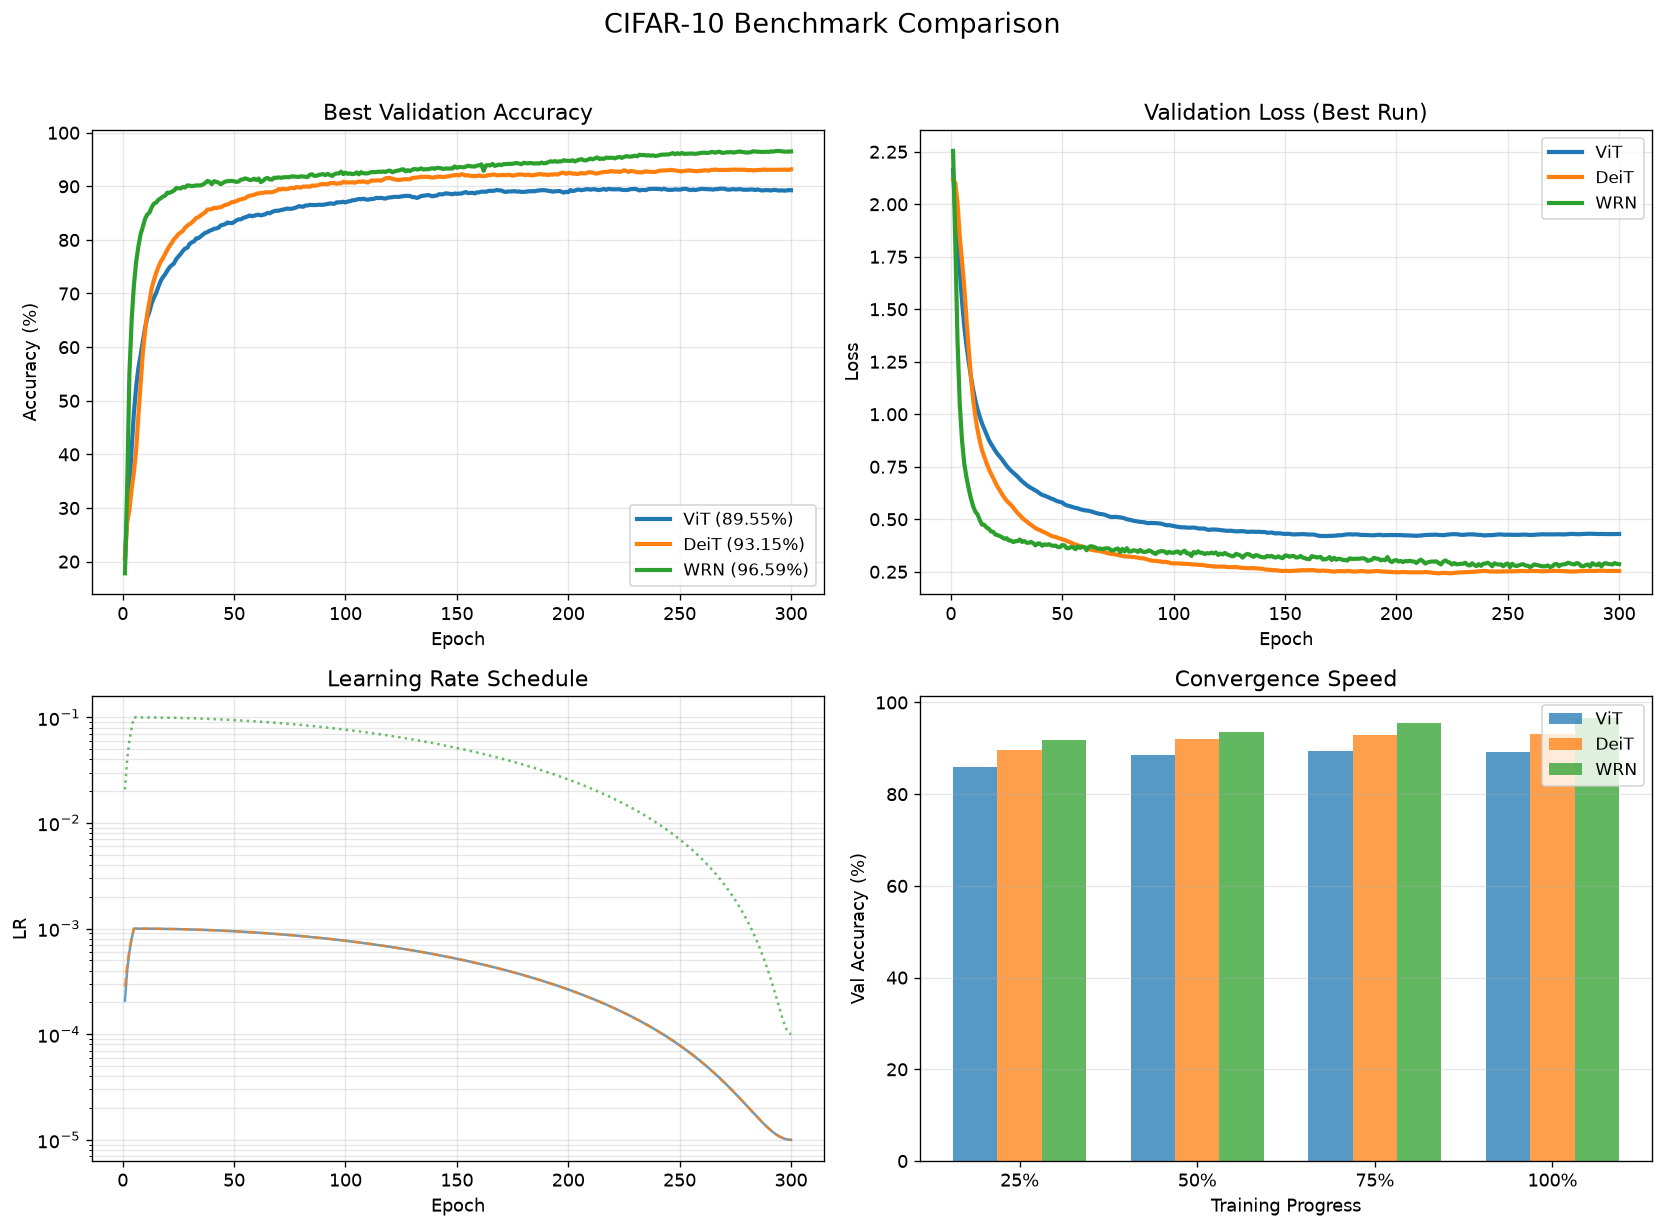

In [25]:
# ---------------------------------------------------------------------------
# All-in-one dashboard figure for reports
# ---------------------------------------------------------------------------

def plot_dashboard(experiments, save_name: str = None):
    """Create a 2x2 dashboard figure for reports."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Top-left: best run val_acc
    ax = axes[0, 0]
    for model_name, runs in experiments.items():
        _, df, best_acc = get_best_run(runs)
        color = MODEL_COLORS.get(model_name, "gray")
        ax.plot(df["epoch"], df["val_acc"],
                label=f"{model_name} ({best_acc:.2f}%)",
                color=color, lw=2.5)
    ax.set_title("Best Validation Accuracy")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy (%)")
    ax.grid(True, alpha=0.3)
    ax.legend()

    # Top-right: best run val_loss
    ax = axes[0, 1]
    for model_name, runs in experiments.items():
        _, df, _ = get_best_run(runs)
        color = MODEL_COLORS.get(model_name, "gray")
        ax.plot(df["epoch"], df["val_loss"],
                label=model_name, color=color, lw=2.5)
    ax.set_title("Validation Loss (Best Run)")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.grid(True, alpha=0.3)
    ax.legend()

    # Bottom-left: LR schedules
    ax = axes[1, 0]
    for model_name, runs in experiments.items():
        color = MODEL_COLORS.get(model_name, "gray")
        ls = MODEL_LINESTYLES.get(model_name, "-")
        for run_name, df in runs.items():
            ax.plot(df["epoch"], df["lr"].clip(lower=0),
                    label=model_name if run_name == list(runs.keys())[0] else "",
                    color=color, ls=ls, lw=1.5, alpha=0.7)
    ax.set_title("Learning Rate Schedule")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("LR")
    ax.set_yscale("log")
    ax.grid(True, alpha=0.3, which="both")

    # Bottom-right: convergence bar chart
    ax = axes[1, 1]
    checkpoints_pct = [0.25, 0.50, 0.75, 1.0]
    x = np.arange(len(checkpoints_pct))
    width = 0.25
    for i, (label, runs) in enumerate(experiments.items()):
        color = MODEL_COLORS.get(label, "gray")
        vals = []
        for run_name, df in runs.items():
            total = len(df)
            row = []
            for pct in checkpoints_pct:
                idx = min(int(total * pct), total - 1)
                row.append(df.iloc[idx]["val_acc"])
            vals.append(row)
        arr = np.array(vals)
        means = arr.mean(axis=0)
        stds = arr.std(axis=0) if arr.shape[0] > 1 else np.zeros_like(means)
        offset = (i - 1) * width
        ax.bar(x + offset, means, width, label=label,
               color=color, alpha=0.75,
               yerr=stds if stds.sum() > 0 else None, capsize=3)
    ax.set_title("Convergence Speed")
    ax.set_xlabel("Training Progress")
    ax.set_ylabel("Val Accuracy (%)")
    ax.set_xticks(x)
    ax.set_xticklabels([f"{int(p * 100)}%" for p in checkpoints_pct])
    ax.grid(True, alpha=0.3, axis="y")
    ax.legend()

    plt.suptitle("CIFAR-10 Benchmark Comparison", fontsize=16, y=1.02)
    plt.tight_layout()
    if save_name:
        save_figure(fig, save_name)
    plt.show()


print("## Dashboard")
plot_dashboard(experiments, save_name="dashboard.png")

In [26]:
# ---------------------------------------------------------------------------
# Cross-architecture summary
# ---------------------------------------------------------------------------

print("## Cross-Architecture Summary\n")

for label, runs in experiments.items():
    meta = metadata[label]
    all_best = [df["best_acc"].max() for df in runs.values()]
    all_final = [df.iloc[-1]["val_acc"] for df in runs.values()]

    run_name, best_df, best_acc_val = get_best_run(runs)
    best_epoch = int(best_df.loc[best_df["best_acc"].idxmax(), "epoch"])

    n_runs = len(runs)
    mean_best = np.mean(all_best)
    std_best = np.std(all_best) if n_runs > 1 else 0
    mean_final = np.mean(all_final)
    std_final = np.std(all_final) if n_runs > 1 else 0

    params_str = (
        f"{meta['param_count'] / 1e6:.3f}M"
        if meta["param_count"] else "N/A"
    )

    print(f"**{label}**  ")
    print(f"- Runs: {n_runs}  ")
    print(f"- Parameters: {params_str}  ")
    print(f"- Best Acc: {mean_best:.2f}% \u00b1 {std_best:.2f}%  ")
    if n_runs > 1:
        print(f"  (range: {min(all_best):.2f}% \u2014 {max(all_best):.2f}%)  ")
    print(f"- Best Epoch: {best_epoch}  ")
    print(f"- Final Val Acc: {mean_final:.2f}% \u00b1 {std_final:.2f}%  ")
    print()

# Winner
best_overall_label = results_df.iloc[0]["Architecture"]
best_overall_acc = results_df.iloc[0]["Best Acc (%)"]
print("---\n")
print(f"**Best overall:** {best_overall_label} with {best_overall_acc:.2f}%")

## Cross-Architecture Summary

**ViT**  
- Runs: 1  
- Parameters: 2.694M  
- Best Acc: 89.55% ± 0.00%  
- Best Epoch: 243  
- Final Val Acc: 89.26% ± 0.00%  

**DeiT**  
- Runs: 1  
- Parameters: 2.856M  
- Best Acc: 93.15% ± 0.00%  
- Best Epoch: 300  
- Final Val Acc: 93.15% ± 0.00%  

**WRN**  
- Runs: 1  
- Parameters: 2.753M  
- Best Acc: 96.59% ± 0.00%  
- Best Epoch: 294  
- Final Val Acc: 96.50% ± 0.00%  

---

**Best overall:** WRN with 96.59%
